# Random Forest

## Functions and libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from fastbook import *
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc

# PATH = "/Users/luanagiusto/TP-1-ML"  # Cambia esto si tu path es diferente
PATH = "C:/Users/julia/ML_TP"

In [2]:
def fit_transform_rf(X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    )

    rf.fit(X_train, y_train)

    proba = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, proba)
    return rf, auc, proba

In [3]:

def plot_feature_importance(rf, X, top_k=20):
    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    top = imp.head(top_k)[::-1]  # invertir para barh ascendente

    plt.figure(figsize=(8, max(4, top_k*0.4)))
    top.plot(kind="barh")
    plt.title(f"Importancias (Random Forest) - Top {top_k}")
    plt.xlabel("Gini importance")
    plt.tight_layout()
    plt.show()

    return imp


## Evaluación ROC-AUC

### Sin oversampling

In [4]:
import duckdb

# Cargar datos
df = duckdb.query("""
    SELECT *
      FROM 'prework_output.parquet'
     WHERE is_test = FALSE
""").to_df()

# Separar features y target
xs = df.drop(columns='target')
y = df['target']

# Entrenar y evaluar
rf, auc, proba = fit_transform_rf(xs, y)
print(f"ROC-AUC (validación): {auc:.6f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ROC-AUC (validación): 0.749571


In [5]:
# 1. Preparar df_test
df_test = duckdb.query("""
    SELECT *
      FROM 'prework_output.parquet'
     WHERE is_test = TRUE
""").to_df()

for col in df_test.select_dtypes("float64"):
    df_test[col] = df_test[col].astype("float32")

# guardar ids
ids = df_test["sk_id_curr"].copy()

# 2. Eliminar columna target si existe
if "target" in df_test.columns:
    df_test = df_test.drop(columns=["target"])

# 3. Alinear columnas con las del train (xs fue tu DataFrame de features de entrenamiento)
train_cols = list(xs.columns)

# Añadir columnas faltantes con 0
for c in train_cols:
    if c not in df_test.columns:
        df_test[c] = 0.0

# Eliminar columnas extra en test (excepto el id)
extra_cols = [c for c in df_test.columns if c not in train_cols and c != "sk_id_curr"]
if extra_cols:
    df_test = df_test.drop(columns=extra_cols)

# Reordenar columnas para que tengan exactamente el mismo orden que en train
df_test = df_test[train_cols]

# 4. Comprobar NaNs y tipos que podrían romper predict
assert df_test.isna().sum().sum() == 0, "Hay NaNs en df_test; imputar antes de predecir"
for col in df_test.select_dtypes("float64"):
    df_test[col] = df_test[col].astype("float32")

# 5. Predecir probabilidades con el modelo entrenado
proba_test = rf.predict_proba(df_test)[:, 1]

# 6. Crear archivo de salida
out = pd.DataFrame({"SK_ID_CURR": ids.values, "TARGET": proba_test})
out.to_csv(os.path.join(PATH, "predictions_test_sin_os_rf.csv"), index=False)
print("Predicciones guardadas en:", os.path.join(PATH, "predictions_test_sin_os_rf.csv"))

Predicciones guardadas en: C:/Users/julia/ML_TP\predictions_test_sin_os_rf.csv


#### Interpretación

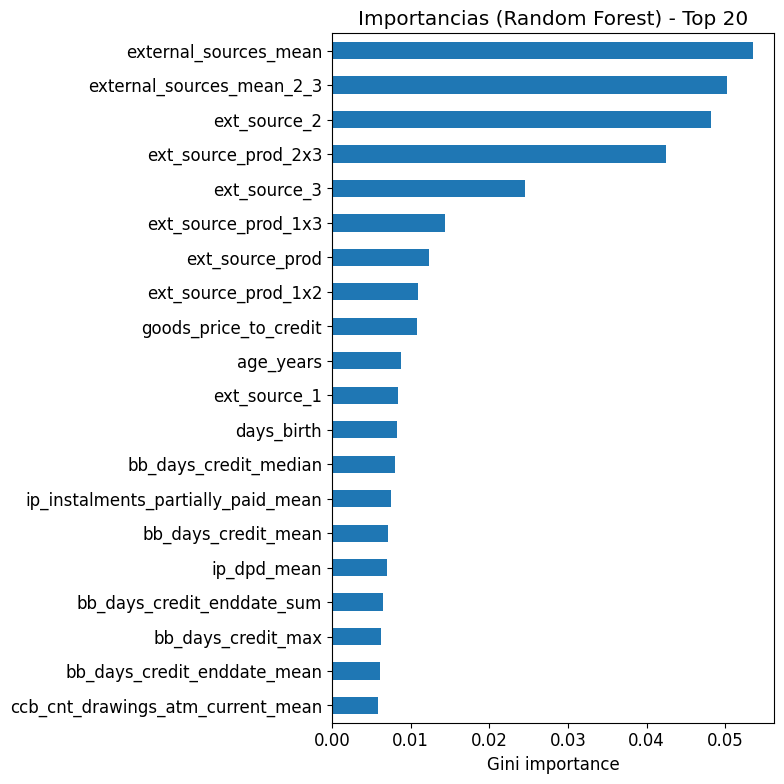

In [6]:
# Calcular y graficar importancias de features
imp = plot_feature_importance(rf, xs, top_k=20)

In [7]:
# Probamos quedarnos con solo features por arriba del threshold de importancia de features
imp = pd.Series(rf.feature_importances_, index=xs.columns).sort_values(ascending=False) # Importancias

# Filtrar features con importancia > threshold
threshold = 0.005
selected_features = imp[imp > threshold].index
X_reduced = xs[selected_features]

print(f"Total features: {xs.shape[1]}")
print(f"Features retenidas (> {threshold*100:.2f}%): {X_reduced.shape[1]}")
print(f"Features descartadas: {xs.shape[1] - X_reduced.shape[1]}")

# Reentrenar con features reducidas
rf_reduced, auc_reduced, proba_reduced = fit_transform_rf(X_reduced, y)
print(f"ROC-AUC (validación, reduced set): {auc_reduced:.6f}")


Total features: 847
Features retenidas (> 0.50%): 23
Features descartadas: 824
ROC-AUC (validación, reduced set): 0.742634


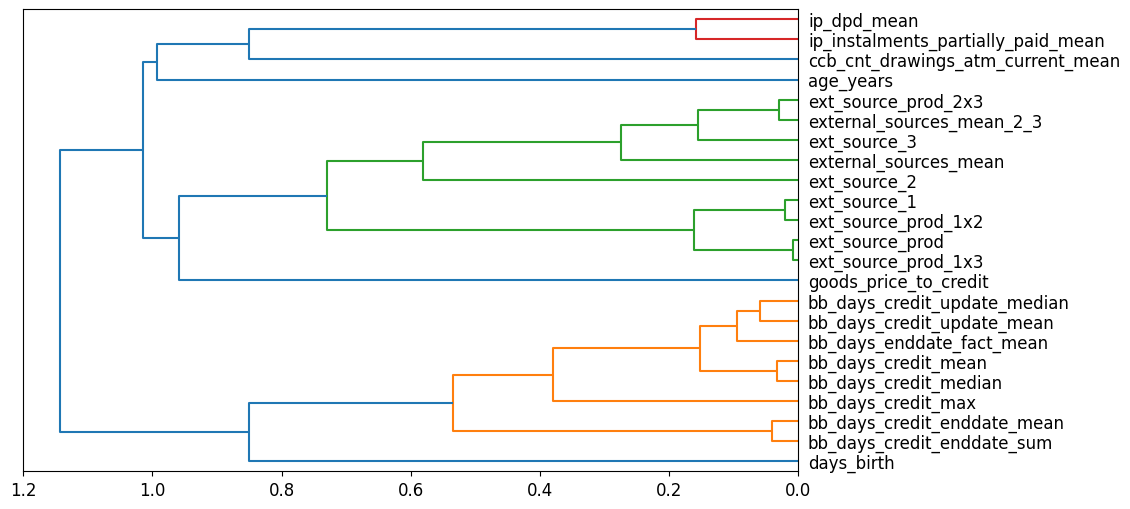

In [8]:
# Estudio de las columnas de a pares para ir viendo cuales "se parecen" en la información que entregan usando fastai 
# haciendo clustering jerarquico de las columnas que las va agrupando según lo parecidas que son.

cluster_columns(X_reduced)

In [9]:
# Para ver cuales columnas tiramos vamos a proponer como candidatos a los grupos de columnas que se formaron en el gráfico anterior y 
# calcular el oob score al sacar cada columna por separado.
def get_oob(df):
    m = RandomForestRegressor(n_estimators=100, min_samples_leaf=15,
        max_samples=50000, max_features=0.5, n_jobs=-1, oob_score=True)
    m.fit(df, y)
    return m.oob_score_

In [10]:
get_oob(X_reduced)

0.07317963186363119

In [11]:
# Partial Dependence: ver cómo las dos variables que resultaron más importantes afectan en la predicción.
top2_features = imp.head(2).index.tolist()
print("Top 2 features:", top2_features)

Top 2 features: ['external_sources_mean', 'external_sources_mean_2_3']


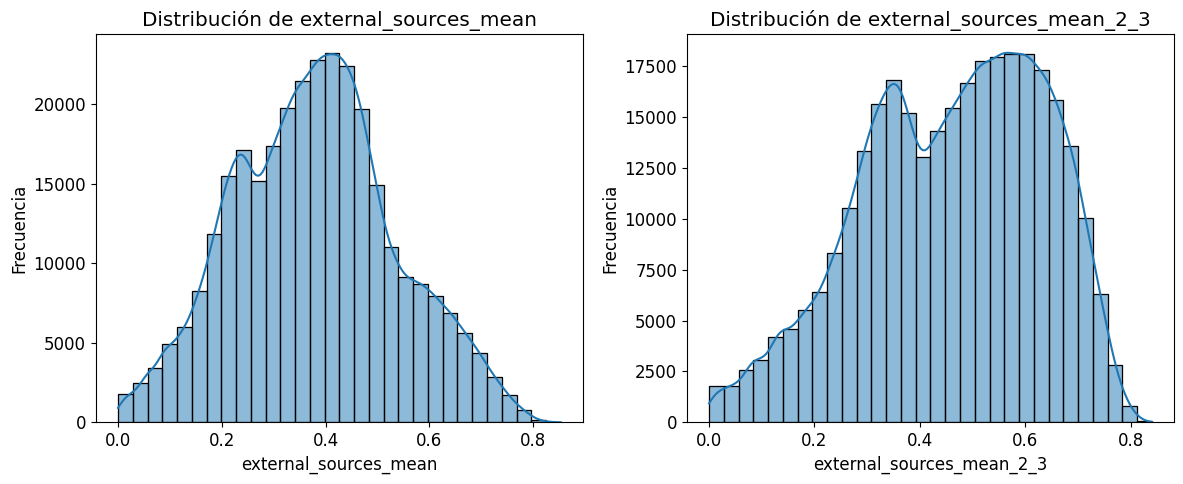

In [12]:
# Veamos primero las distribuciones de estas dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, feat in enumerate(top2_features):
    sns.histplot(xs[feat], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


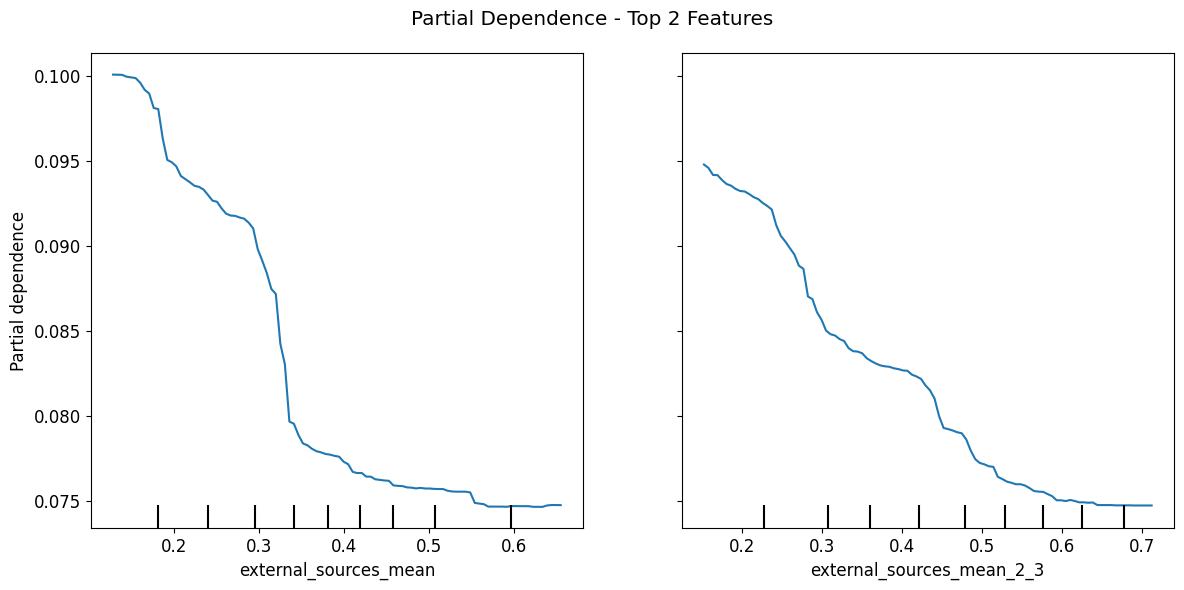

In [13]:
# Gráfico conjunto de las 2 features más importantes
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    rf, xs, top2_features, ax=ax
)
plt.suptitle("Partial Dependence - Top 2 Features")
plt.tight_layout()
plt.show()

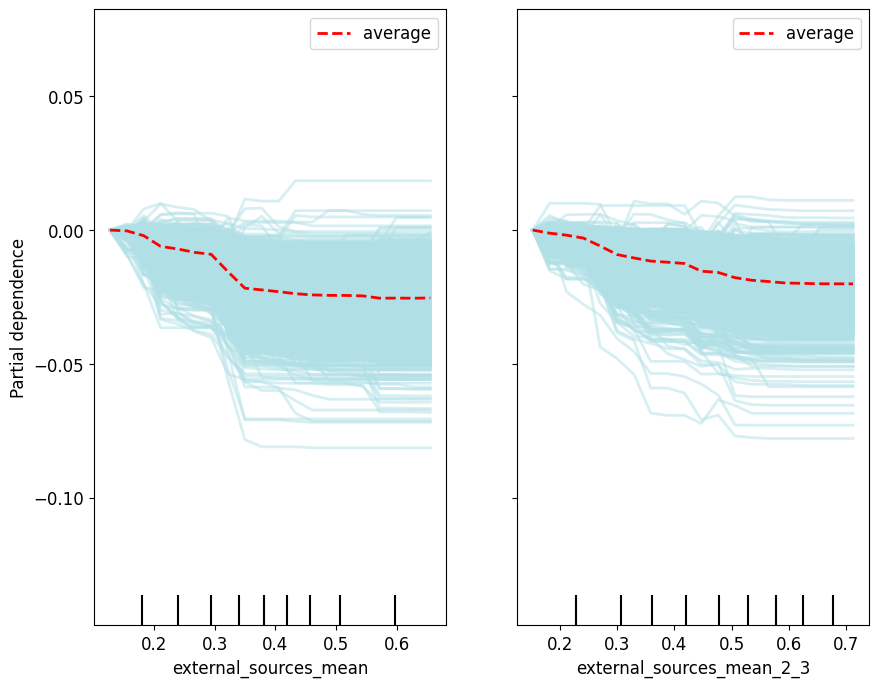

In [14]:
# Gráfico Individual conditional expectation. 
# Este gráfico es análogo al PDP pero no toma el valor promedio si no que muestra la predicción de todas las filas.
fig, ax = plt.subplots(figsize=(10, 8))

common_params = {"grid_resolution": 20, "random_state": 0}
features_info = {"features": top2_features, "kind": "both", "centered": True}
display = PartialDependenceDisplay.from_estimator(
    rf,
    xs,
    **features_info,
    ax=ax,
    line_kw={"color": "red", "linewidth": 2},
    ice_lines_kw={"color": "#B0E0E6", "alpha": 0.5},
    **common_params,
)


In [15]:
gc.collect()

3

### Con oversampling

In [16]:
# Cargar datos
df_os = pd.read_parquet(os.path.join(PATH, 'prework_train_output_oversampled.parquet'))

for col in df_os.select_dtypes("float64"):
    df_os[col] = df_os[col].astype("float32")
    
# Separar features y target
y = df_os.pop('target')
xs = df_os

# Entrenar y evaluar
rf, auc, proba = fit_transform_rf(xs, y)
print(f"ROC-AUC (validación): {auc:.6f}")

ROC-AUC (validación): 0.831207


#### Interpretación

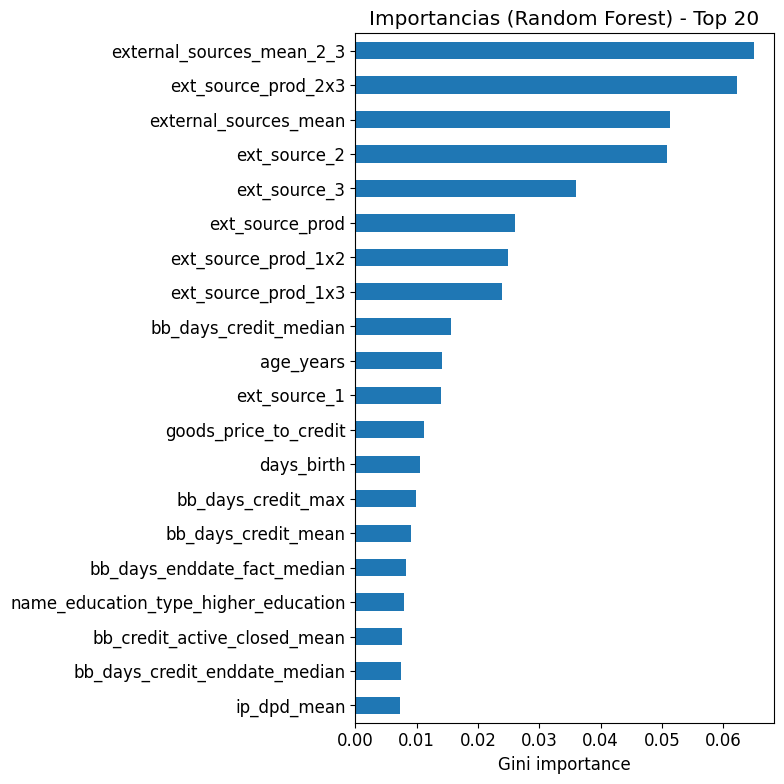

In [17]:
# Calcular y graficar importancias de features
imp = plot_feature_importance(rf, xs, top_k=20)

In [18]:
# Probamos quedarnos con solo features por arriba del threshold de importancia de features
imp = pd.Series(rf.feature_importances_, index=xs.columns).sort_values(ascending=False) # Importancias

# Filtrar features con importancia > threshold
threshold = 0.005
selected_features = imp[imp > threshold].index
X_reduced = xs[selected_features]

print(f"Total features: {xs.shape[1]}")
print(f"Features retenidas (> {threshold*100:.2f}%): {X_reduced.shape[1]}")
print(f"Features descartadas: {xs.shape[1] - X_reduced.shape[1]}")

# Reentrenar con features reducidas
rf_reduced, auc_reduced, proba_reduced = fit_transform_rf(X_reduced, y)
print(f"ROC-AUC (validación, reduced set): {auc_reduced:.6f}")


Total features: 846
Features retenidas (> 0.50%): 31
Features descartadas: 815
ROC-AUC (validación, reduced set): 0.806179


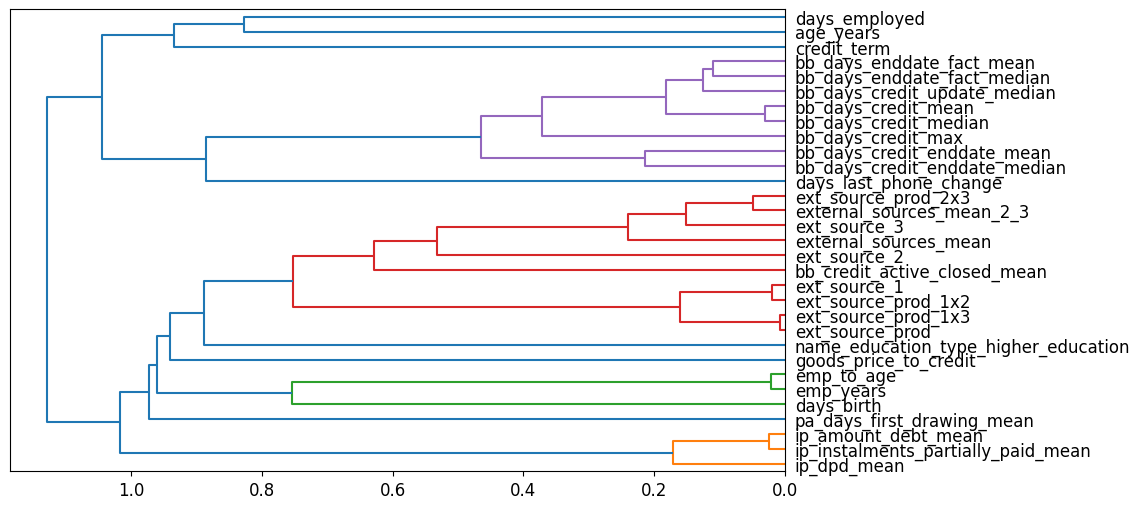

In [19]:
# Estudio de las columnas de a pares para ir viendo cuales "se parecen" en la información que entregan usando fastai 
# haciendo clustering jerarquico de las columnas que las va agrupando según lo parecidas que son.

cluster_columns(X_reduced)

## Model selection

In [20]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import random

def random_cv_rf_reduced(X, y, selected_features, param_distributions,
                         n_iter=10, sample_size=0.3, n_splits=3, random_state=42):
    """
    Búsqueda aleatoria de hiperparámetros para RandomForest usando solo las columnas
    en selected_features.
    """
    np.random.seed(random_state)
    random.seed(random_state)

    # Preparar muestra
    if 0 < sample_size < 1:
        sample_n = int(len(X) * sample_size)
    elif isinstance(sample_size, int) and sample_size >= 1:
        sample_n = min(sample_size, len(X))
    else:
        raise ValueError("sample_size debe ser fracción (0-1) o entero >=1")

    indices = np.random.choice(len(X), size=sample_n, replace=False)
    X_sample = X.iloc[indices][selected_features].reset_index(drop=True)
    y_sample = y.iloc[indices].reset_index(drop=True)

    print(f"Tamaño original del dataset: {len(X)}")
    print(f"Tamaño de la muestra usada en búsqueda: {len(X_sample)}")
    print(f"Usando {len(selected_features)} features seleccionadas")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for i in range(n_iter):
        # Muestreo aleatorio de parámetros (listas o tuplas)
        params = {}
        for key, value in param_distributions.items():
            if isinstance(value, list):
                params[key] = random.choice(value)
            elif isinstance(value, tuple) and len(value) == 2:
                params[key] = np.random.uniform(value[0], value[1])
            else:
                params[key] = value

        # Casting/rounding para parámetros enteros
        if 'n_estimators' in params:
            params['n_estimators'] = int(round(params['n_estimators']))
        if 'max_depth' in params and params['max_depth'] is not None:
            params['max_depth'] = None if params['max_depth'] <= 0 else int(round(params['max_depth']))
        if 'min_samples_leaf' in params:
            params['min_samples_leaf'] = int(round(params['min_samples_leaf']))
        if 'min_samples_split' in params:
            params['min_samples_split'] = int(round(params['min_samples_split']))
        if 'max_features' in params:
            mf = params['max_features']
            if isinstance(mf, float):
                params['max_features'] = float(mf)
            elif isinstance(mf, int):
                params['max_features'] = int(mf)
            # si es str (p.ej. 'sqrt') lo dejamos

        fold_scores = []
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_sample), 1):
            X_train, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
            y_train, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]

            model = RandomForestClassifier(random_state=random_state, n_jobs=-1, **params)
            model.fit(X_train, y_train)

            y_pred = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred)
            fold_scores.append(auc)

        mean_auc = float(np.mean(fold_scores))
        std_auc = float(np.std(fold_scores))

        results.append({
            'params': params,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'fold_scores': fold_scores
        })

        print(f"\nIteración {i+1}/{n_iter}")
        print(f"Parámetros: {params}")
        print(f"AUC medio: {mean_auc:.6f} (±{std_auc:.6f})")
        print("Scores por fold:", fold_scores)
        print("-" * 80)

    results.sort(key=lambda x: x['mean_auc'], reverse=True)
    return results

In [21]:
# Definir distribuciones de hiperparámetros
param_distributions_rf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.2, 0.3, 0.4, 'sqrt'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}

# Ejecutar búsqueda aleatoria con validación cruzada
results_rf = random_cv_rf_reduced(xs, y, selected_features,
                                  param_distributions_rf,
                                  n_iter=15, sample_size=0.3, n_splits=3, random_state=42)

# ver top 3
for i, r in enumerate(results_rf[:3], 1):
    print(i, r['mean_auc'], r['params'])

Tamaño original del dataset: 513799
Tamaño de la muestra usada en búsqueda: 154139
Usando 31 features seleccionadas

Iteración 1/15
Parámetros: {'n_estimators': 800, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10, 'max_features': 0.4, 'bootstrap': True, 'class_weight': None}
AUC medio: 0.766576 (±0.001585)
Scores por fold: [0.764345986468969, 0.7675014067454469, 0.7678811875854298]
--------------------------------------------------------------------------------

Iteración 2/15
Parámetros: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10, 'max_features': 0.2, 'bootstrap': False, 'class_weight': None}
AUC medio: 0.764476 (±0.001437)
Scores por fold: [0.7624494465629633, 0.7653587695737938, 0.7656201121892733]
--------------------------------------------------------------------------------

Iteración 3/15
Parámetros: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 0.2, 'bootstrap': Tr

In [22]:
# Entrenar y evaluar modelo final con los mejores hiperparámetros
best_params = results_rf[0]['params']
rf_reduced_final = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_reduced_final.fit(xs[selected_features], y)
# guardar rf_reduced_final y usar rf_reduced_final.predict_proba(df_test[selected_features])[:,1]

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predict & submission

In [23]:
# Preparar df_test
df_test = pd.read_parquet(os.path.join(PATH, "prework_test_output.parquet"))

# mantener dtypes como hiciste
for col in df_test.select_dtypes("float64"):
    df_test[col] = df_test[col].astype("float32")

# Alinear test con el set reducido de features
reduced_cols = list(selected_features)

# Añadir columnas faltantes con 0
for c in reduced_cols:
    if c not in df_test.columns:
        df_test[c] = 0.0

# Eliminar columnas extra en test (excepto el id)
extra_cols = [c for c in df_test.columns if c not in reduced_cols and c != "sk_id_curr"]
if extra_cols:
    df_test = df_test.drop(columns=extra_cols)

# Reordenar columnas para que coincidan exactamente con reduced_cols
df_test_reduced = df_test[reduced_cols]

# Comprobar y convertir dtypes / NaNs
if df_test_reduced.isna().sum().sum() != 0:
    raise ValueError("Hay NaNs en df_test_reduced; imputar con la misma estrategia que en train")
for col in df_test_reduced.select_dtypes("float64"):
    df_test_reduced[col] = df_test_reduced[col].astype("float32")

# Predecir con el modelo reentrenado sobre el reduced set
proba_test = rf_reduced_final.predict_proba(df_test_reduced)[:, 1]

# Guardar submission
FILENAME = "predictions_test_reduced_final_rf.csv"
out = pd.DataFrame({"SK_ID_CURR": ids.values, "TARGET": proba_test})
out.to_csv(os.path.join(PATH, FILENAME), index=False)
print("Predicciones guardadas en:", os.path.join(PATH, FILENAME))

Predicciones guardadas en: C:/Users/julia/ML_TP\predictions_test_reduced_final_rf.csv
